In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Scikit-learn datasets & model selection
from sklearn.datasets import (
    make_classification,
    make_regression,
    load_breast_cancer,
    load_diabetes
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# Regression models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    ConfusionMatrixDisplay
)

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Random seed
np.random.seed(42)

print("All libraries loaded successfully!")
print(f"NumPy: {np.__version__} | Pandas: {pd.__version__}")

All libraries loaded successfully!
NumPy: 2.0.2 | Pandas: 2.2.2


In [3]:
cancer = load_breast_cancer()

X_clf, y_clf = cancer.data, cancer.target   # 0 = malignant, 1 = benign

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=42
)

# Feature scaling important for Logistic Regression and SVM
scaler_c = StandardScaler()

X_train_c = scaler_c.fit_transform(X_train_c)
X_test_c = scaler_c.transform(X_test_c)


# -------------------------------
# Regression: Diabetes Dataset
# -------------------------------

diabetes = load_diabetes()

X_reg, y_reg = diabetes.data, diabetes.target

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

scaler_r = StandardScaler()

X_train_r = scaler_r.fit_transform(X_train_r)
X_test_r = scaler_r.transform(X_test_r)


# -------------------------------
# Quick data summary
# -------------------------------

print("CLASSIFICATION DATASET (Breast Cancer)")

print(f"Train: {X_train_c.shape} | Test: {X_test_c.shape}")

print(
    f"Class balance -> Malignant: {(y_clf == 0).sum()} | "
    f"Benign: {(y_clf == 1).sum()}"
)

print("\nREGRESSION DATASET (Diabetes)")

print(f"Train: {X_train_r.shape} | Test: {X_test_r.shape}")

print(f"Target range: [{y_reg.min():.0f}, {y_reg.max():.0f}]")

CLASSIFICATION DATASET (Breast Cancer)
Train: (455, 30) | Test: (114, 30)
Class balance -> Malignant: 212 | Benign: 357

REGRESSION DATASET (Diabetes)
Train: (353, 10) | Test: (89, 10)
Target range: [25, 346]


In [4]:
#task
data=load_breast_cancer()
x=data.data
y=data.target
#feature
print("feature name")
print(data.feature_names[:5])

feature name
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']


In [6]:
#imbalance ratio

malignant_count=np.sum(y==0)
benign_count=np.sum(y==1)

total_count=len(y)

malignant_ratio=malignant_count/total_count
benign_ratio=benign_count/total_count

print("malignant ratio",malignant_ratio)
print("benign ratio",benign_ratio)


malignant ratio 0.37258347978910367
benign ratio 0.6274165202108963


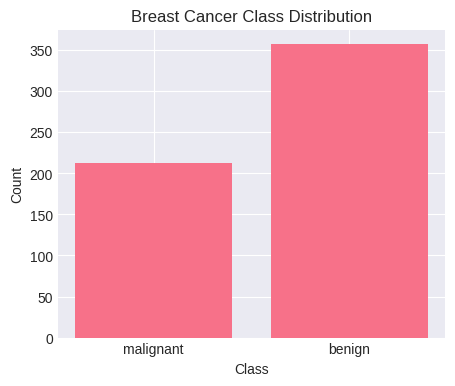

In [8]:
# Task 3: Bar chart for class distribution

import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

# Load dataset
cancer = load_breast_cancer()

# Count classes
malignant = sum(cancer.target == 0)
benign = sum(cancer.target == 1)

labels = ['malignant', 'benign']
counts = [malignant, benign]

# Create figure
plt.figure(figsize=(5,4))

# Bar chart
plt.bar(labels, counts)

# Labels and title
plt.title("Breast Cancer Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

# Display chart
plt.show()


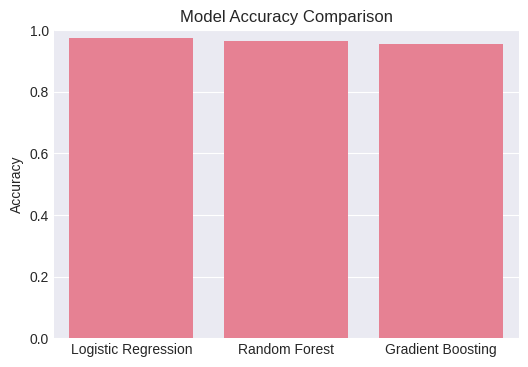

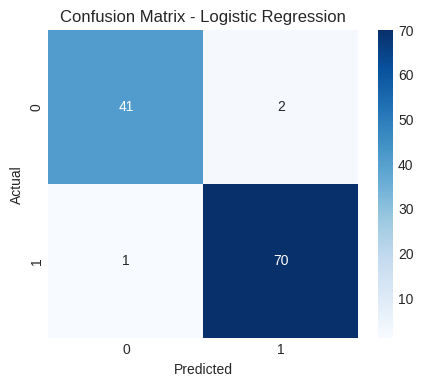

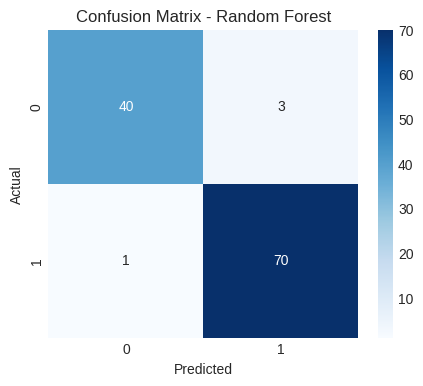

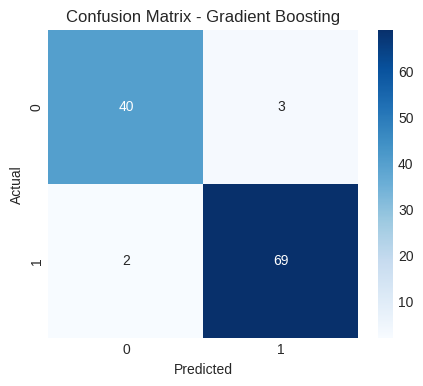

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(6,4))
accuracies = [result['accuracy'] for result in results.values()]
model_names = list(results.keys())
sns.barplot(x=model_names, y=accuracies)
plt.ylim(0, 1)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()


for name, result in results.items():
    plt.figure(figsize=(5,4))
    sns.heatmap(result['confusion_matrix'], annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [11]:
# Task: Accuracy and Confusion Matrix

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

# Load dataset
data = load_breast_cancer()

x = data.data
y = data.target

# Split dataset
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# Create model
model = LogisticRegression(max_iter=1000)

# Train model
model.fit(x_train, y_train)

# Prediction
y_pred = model.predict(x_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Extract TN, FP, FN, TP
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

print("TN:", TN)
print("FP:", FP)
print("FN:", FN)
print("TP:", TP)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Confusion Matrix:
[[39  4]
 [ 1 70]]
TN: 39
FP: 4
FN: 1
TP: 70
Accuracy: 0.956140350877193
